In [17]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import  CatBoostRegressor
from xgboost import XGBRegressor

In [18]:
df = pd.read_csv('data/stud.csv')

In [19]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [20]:
X = df.drop(columns=['math_score'])
Y = df['math_score']

In [21]:
numerical_features = X.select_dtypes(exclude='str').columns
categorical_features = X.select_dtypes(include='str').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import  ColumnTransformer

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", categorical_transformer, categorical_features),
        ("StandardScaler", numeric_transformer, numerical_features)
    ]
)

In [22]:
X.shape

(1000, 7)

In [23]:
X = preprocessor.fit_transform(X)

In [24]:
from sklearn.model_selection import  train_test_split

x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)

(800, 19)
(200, 19)


In [25]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2e = r2_score(true, predicted) # r square error
    return mae, mse, rmse, r2e

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for name, model in models.items():
    model.fit(x_train, y_train)  # train the model

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # evaluate on train set
    train_mae, train_mse, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)

    # evaluate on test set
    test_mae, test_mse, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    model_list.append(name)
    r2_list.append(test_r2)

    print(name)
    print('Model performance for Training set')
    print(f"- RMSE: {train_rmse:.4f}")
    print(f"- MAE: {train_mae:.4f}")
    print(f"- R2 Score: {train_r2:.4f}")

    print('----------------------------------')

    print('Model performance for Test set')
    print(f"- RMSE: {test_rmse:.4f}")
    print(f"- MAE: {test_mae:.4f}")
    print(f"- R2 Score: {test_r2:.4f}")

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- RMSE: 5.3231
- MAE: 4.2667
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- RMSE: 5.3940
- MAE: 4.2148
- R2 Score: 0.8804


Lasso
Model performance for Training set
- RMSE: 6.5938
- MAE: 5.2063
- R2 Score: 0.8071
----------------------------------
Model performance for Test set
- RMSE: 6.5197
- MAE: 5.1579
- R2 Score: 0.8253


Ridge
Model performance for Training set
- RMSE: 5.3233
- MAE: 4.2650
- R2 Score: 0.8743
----------------------------------
Model performance for Test set
- RMSE: 5.3904
- MAE: 4.2111
- R2 Score: 0.8806


K-Neighbors Regressor
Model performance for Training set
- RMSE: 5.7079
- MAE: 4.5168
- R2 Score: 0.8555
----------------------------------
Model performance for Test set
- RMSE: 7.2530
- MAE: 5.6210
- R2 Score: 0.7838


Decision Tree
Model performance for Training set
- RMSE: 0.2795
- MAE: 0.0187
- R2 Score: 0.9997
----------------------------------
Model performance fo

In [29]:
results = pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by="R2_Score", ascending=False)
print(results)

                Model Name  R2_Score
2                    Ridge  0.880593
0        Linear Regression  0.880433
5  Random Forest Regressor  0.853348
7    CatBoosting Regressor  0.851632
8       AdaBoost Regressor  0.849123
6             XGBRegressor  0.827797
1                    Lasso  0.825320
3    K-Neighbors Regressor  0.783813
4            Decision Tree  0.724191


In [30]:
best_model_name = results.iloc[0]['Model Name']
best_model = models[best_model_name]

print(f"Best model: {best_model_name}, R2 Score: {results.iloc[0]['R2_Score']:.4f}")

Best model: Ridge, R2 Score: 0.8806


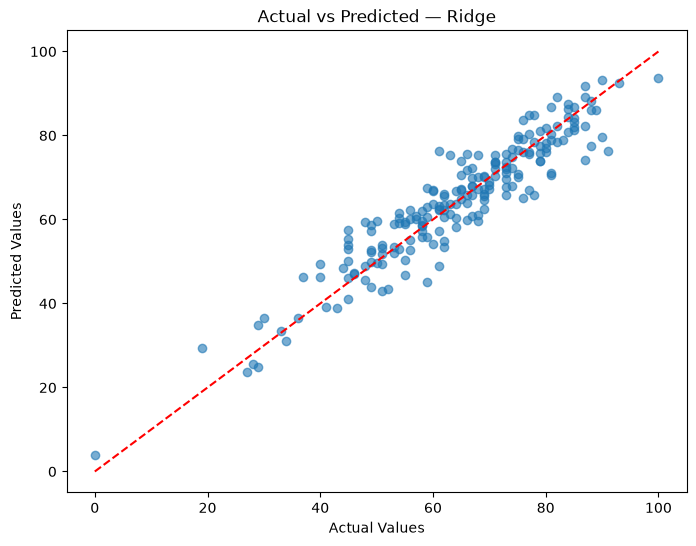

In [32]:
import matplotlib.pyplot as plt

y_pred_best = best_model.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.show()